![image.png](https://i.imgur.com/a3uAqnb.png)

# Neural Network Regression for California Housing Prices - Homework Assignment

In this homework, you will implement a **Neural Network for regression** to predict the median value of California houses. This project will help you understand the fundamentals of neural networks applied to regression tasks.

## 📌 Project Overview
- **Task**: Predict median house values in California
- **Architecture**: Multi-layer Perceptron (MLP) for regression
- **Dataset**: California Housing dataset (provided)
- **Goal**: Build an accurate regression model using PyTorch

## 📚 Learning Objectives
By completing this assignment, you will:
- Understand neural networks for regression problems
- Learn data preprocessing and feature engineering
- Implement a custom neural network architecture
- Practice training, validation, and evaluation
- Learn about regression metrics and model performance


## 1️⃣ Initial Setup and Library Installation

**Task**: Set up the environment and install necessary libraries.

In [ ]:
from IPython.display import clear_output

In [ ]:
# Incase you run this notebook outside colab (where the libraries aren't already pre-installed)

# %pip install torch
# %pip install matplotlib
# %pip install scikit-learn

clear_output()


## 2️⃣ Import Libraries and Configuration

**Task**: Import all necessary libraries and set up configuration parameters.

**Requirements**:
- Import PyTorch and neural network modules
- Import data processing libraries (pandas, sklearn)
- Import visualization libraries
- Set random seeds for reproducibility
- Configure hyperparameters with reasonable values

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ADD
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

BATCH_SIZE = 64          # Batch size for training
LEARNING_RATE = 0.001    # Learning rate for optimizer
NUM_EPOCHS = 100         # Number of training epochs
HIDDEN_SIZE = 128        # Size of hidden layers
NUM_HIDDEN_LAYERS = 3    # Number of hidden layers
VALIDATION_SPLIT = 0.3   # Validation split ratio (inside of train_set)

Using device: cpu


## 3️⃣ Data Loading and Exploration

**Task**: Load the California housing dataset and explore its structure.

**Requirements**:
- Download and load the dataset
- Display basic information about the data
- Check for missing values
- Understand the features and target variable

In [ ]:
# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [ ]:
# TODO: List files in the dataset directory
files = os.listdir(path)
print(f"Files in directory: {files}")

Files in directory: ['housing.csv']


In [ ]:
# TODO: Load the dataset
csv_path = os.path.join(path, 'housing.csv')
california_data = pd.read_csv(csv_path)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
california_data.head() # check

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
print("\nMissing values:")
print(california_data.isnull().sum())
print("\nBasic statistics:")
california_data.describe()


Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Basic statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



## 4️⃣ Data Preprocessing and Feature Engineering

**Task**: Clean and prepare the data for neural network training.

**Requirements**:
- Handle missing values if any
- Encode categorical variables
- Scale numerical features
- Split features and target
- Create train/validation/test splits

In [ ]:
california_data = california_data.copy() # copy the dataset, operate on this

In [ ]:
# TODO: Handle missing values (fill with median for numerical columns)
california_data['total_bedrooms'] = california_data['total_bedrooms'].fillna(california_data['total_bedrooms'].median())

# TODO: Feature engineering - create new features - optional
california_data['rooms_per_household'] = california_data['total_rooms'] / california_data['households'] # combination feature1
california_data['bedrooms_per_room'] = california_data['total_bedrooms'] / california_data['total_rooms'] # combination feature2
california_data['population_per_household'] = california_data['population'] / california_data['households'] # combination feature3

# TODO: Separate features from target
X = california_data.drop('median_house_value', axis=1)
y = california_data['median_house_value'].values

# TODO: Encode the categorical ocean_proximity column
X = pd.get_dummies(X, columns=['ocean_proximity']) # one-hot encoder

# TODO: Scale the features for better neural network performance
scaler = StandardScaler() # use standardization
X_scaled = scaler.fit_transform(X)

# ADD: Target Scaler
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

# TODO: Convert to numpy arrays
# X_scaled is already a numpy array from scaler, y needs reshaping
y = y.reshape(-1, 1) # -1: row auto: 1: 1 column

# TODO: Split the data into train, validation, and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=VALIDATION_SPLIT, random_state=42)

# TODO: Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)


## 5️⃣ Neural Network Architecture

**Task**: Design and implement a neural network for regression.

**Requirements**:
- Create a multi-layer perceptron (MLP)
- Use appropriate activation functions
- Ensure proper input/output dimensions
- Use suitable architecture for regression

In [ ]:
class HousePricePredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_hidden_layers):
        super(HousePricePredictor, self).__init__()

        layers = []
        # TODO: Input layer
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())

        # TODO: Hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())

        # TODO: Output layer (single neuron for regression)
        layers.append(nn.Linear(hidden_size, 1))

        # TODO: Create sequential model
        self.main = nn.Sequential(*layers)

    def forward(self, x):
        # TODO: Forward pass through the network
        return self.main(x)

# TODO: Initialize the model
input_dim = X_train.shape[1]
model = HousePricePredictor(input_dim, HIDDEN_SIZE, NUM_HIDDEN_LAYERS).to(device)
print(model)

# TODO: Test the model with a sample input
sample_input = X_train[:5].to(device)
with torch.no_grad(): # save comp
    sample_output = model(sample_input)
print("\nSample output shape:", sample_output.shape)
print("Sample predictions:\n", sample_output)

HousePricePredictor(
  (main): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

Sample output shape: torch.Size([5, 1])
Sample predictions:
 tensor([[ 7.2836e-03],
        [ 5.9095e-03],
        [-1.4469e-02],
        [ 1.1770e-02],
        [-3.9848e-05]])



## 6️⃣ Loss Function and Optimizer

**Task**: Set up appropriate loss function and optimizer for regression.

**Requirements**:
- Choose suitable loss function for regression
- Initialize optimizer with hyperparameters

In [ ]:
# TODO: Define loss function for regression
criterion = nn.MSELoss() # MSE for regression

# TODO: Define optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


## 7️⃣ Training Loop with Validation

**Task**: Implement a comprehensive training loop with validation.

**Requirements**:
- Train the model for specified epochs
- Track training and validation losses
- Save the best model based on validation performance
- Display training progress

In [ ]:
# TODO: Create DataLoader for batch processing
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# TODO: Initialize tracking variables
train_losses = []
val_losses = []
best_val_loss = float('inf')

# TODO: Training loop
for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # TODO: Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # TODO: Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation phase
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            # TODO: Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()

    # Calculate average losses
    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # store the best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')


    # TODO: Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')


Epoch [10/100], Train Loss: 0.2141, Val Loss: 0.2282
Epoch [20/100], Train Loss: 0.1885, Val Loss: 0.2146
Epoch [30/100], Train Loss: 0.1663, Val Loss: 0.2093
Epoch [40/100], Train Loss: 0.1498, Val Loss: 0.2207
Epoch [50/100], Train Loss: 0.1371, Val Loss: 0.2167
Epoch [60/100], Train Loss: 0.1226, Val Loss: 0.2188
Epoch [70/100], Train Loss: 0.1097, Val Loss: 0.2219
Epoch [80/100], Train Loss: 0.0998, Val Loss: 0.2293
Epoch [90/100], Train Loss: 0.0879, Val Loss: 0.2476
Epoch [100/100], Train Loss: 0.0797, Val Loss: 0.2326




## 8️⃣ Model Evaluation and Testing

**Task**: Evaluate the trained model on the test set and calculate regression metrics.

**Requirements**:
- Make predictions on test set
- Calculate multiple regression metrics
- Analyze model performance

In [ ]:
# TODO: Set the model to eval mode
model.load_state_dict(torch.load('best_model.pth')) # load the best model
model.eval()

# TODO: Make predictions on test set
with torch.no_grad():
    X_test_device = X_test.to(device)
    y_pred_tensor = model(X_test_device)
    y_pred = y_pred_tensor.cpu().numpy()
    y_true = y_test.numpy()
    # use inverse
    y_pred_real = y_scaler.inverse_transform(y_pred)
    y_true_real = y_scaler.inverse_transform(y_true)

# TODO: Calculate regression metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

Model Evaluation Metrics:
Mean Squared Error (MSE): 0.21
Root Mean Squared Error (RMSE): 0.46
Mean Absolute Error (MAE): 0.31
R-squared Score (R2): 0.7840


## 9️⃣ Visualization and Analysis

**Task**: Create visualizations to analyze model performance and training progress.

**Requirements**:
- Plot training and validation loss curves
- Analyze residuals

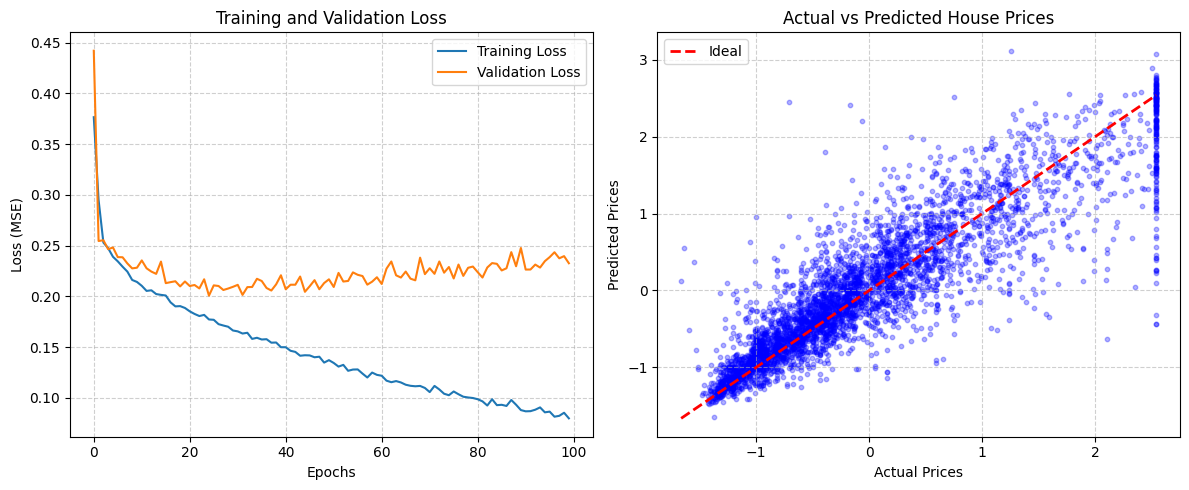


Sample Predictions (First 10 rows):


,Actual Price,Predicted Price,Absolute Error
0,47700.003906,44800.003906,0.025131
1,45800.003906,95463.132812,0.430383
2,500001.000000,315913.218750,1.595314
3,218600.000000,288741.187500,0.607847
4,278000.000000,265390.000000,0.109279
5,158700.000000,189142.656250,0.263818
6,198200.000000,353137.531250,1.342697
7,157500.000000,216809.078125,0.513975
8,340000.000000,209396.343750,1.131818
9,446600.031250,447288.281250,0.005965


In [ ]:
# TODO: Plot training and validation loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# TODO: Plot predictions vs actual values
plt.subplot(1, 2, 2)
plt.scatter(y_true, y_pred, alpha=0.3, color='blue', s=10)

# baseline: y=x
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Ideal')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# TODO: Show some sample predictions
'''
  the first 10 predictions
'''
print("\nSample Predictions (First 10 rows):")
comparison_df = pd.DataFrame({
    'Actual Price': y_true_real.flatten(),
    'Predicted Price': y_pred_real.flatten(),
    'Absolute Error': np.abs(y_true.flatten() - y_pred.flatten())
})
display(comparison_df.head(10))


**overfitting!!!**

## 🔟 <font color='red'>**Improvement**</font>
To improve the model's generalization, we add:
1. **Dropout (0.2)**: Randomly zeros some of the elements of the input tensor with probability 0.2.
2. **Weight Decay (1e-4)**: Adds an L2 penalty to the Adam optimizer.

In [ ]:
class ImprovedHousePricePredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_hidden_layers, dropout_prob=0.2):
        super(ImprovedHousePricePredictor, self).__init__()
        layers = []

        # Input layer
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_prob))

        # Hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob)) ### randomly drop some cells !!!

        # Output layer
        layers.append(nn.Linear(hidden_size, 1))
        self.main = nn.Sequential(*layers)

    def forward(self, x):
        return self.main(x)

# Initialize the improved model
model = ImprovedHousePricePredictor(input_dim, HIDDEN_SIZE, NUM_HIDDEN_LAYERS).to(device)

# Define optimizer with Weight Decay (L2 regularization)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) ### AdamW !!!

print("Improved model initialized with Dropout and Weight Decay.")

Improved model initialized with Dropout and Weight Decay.


Starting training with Dropout and Weight Decay...
Epoch [20/100], Train Loss: 0.2320, Val Loss: 0.2207
Epoch [40/100], Train Loss: 0.2065, Val Loss: 0.2053
Epoch [60/100], Train Loss: 0.1945, Val Loss: 0.2008
Epoch [80/100], Train Loss: 0.1870, Val Loss: 0.1955
Epoch [100/100], Train Loss: 0.1799, Val Loss: 0.1944


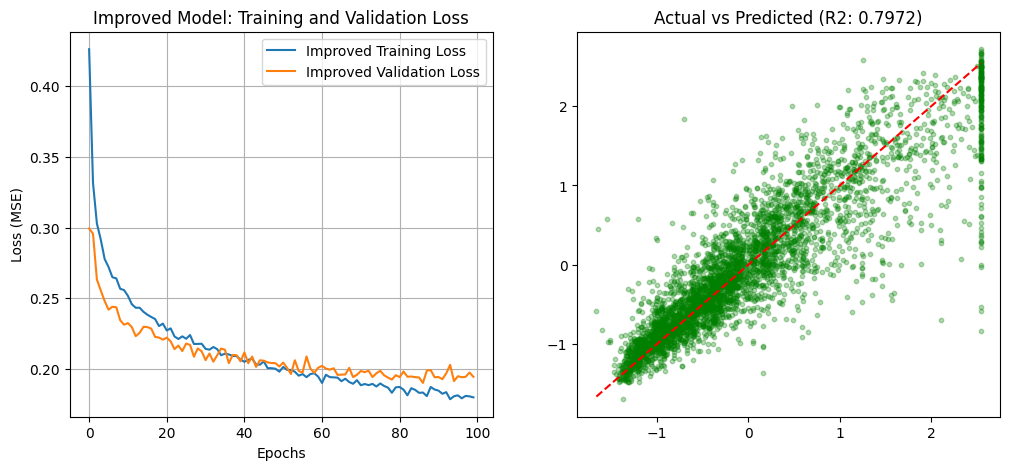


Improved Model Predictions (First 10 rows):


,Actual Price (USD),Predicted Price (USD),Absolute Error (Scaled)
0,47700.003906,51940.644531,0.036750
1,45800.003906,103525.515625,0.500252
2,500001.000000,267727.125000,2.012897
3,218600.000000,269789.656250,0.443612
4,278000.000000,262340.500000,0.135706
5,158700.000000,190453.500000,0.275177
6,198200.000000,359951.125000,1.401743
7,157500.000000,186440.421875,0.250799
8,340000.000000,218927.125000,1.049224
9,446600.031250,458006.343750,0.098848


In [ ]:
# 1. Reset tracking variables
train_losses_improved = []
val_losses_improved = []
best_val_loss_imp = float('inf')

# 2. Training Loop with the Improved Model
print("Starting training with Dropout and Weight Decay...")
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            val_loss += criterion(outputs, batch_y).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses_improved.append(train_loss)
    val_losses_improved.append(val_loss)

    if val_loss < best_val_loss_imp:
        best_val_loss_imp = val_loss
        torch.save(model.state_dict(), 'best_model_improved.pth')

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

# 3. Evaluation on Test Set
model.load_state_dict(torch.load('best_model_improved.pth'))
model.eval()
with torch.no_grad():
    y_pred_imp = model(X_test.to(device)).cpu().numpy()
    r2_imp = r2_score(y_test, y_pred_imp)

    # Inverse transform to get actual prices in USD
    y_pred_imp_real = y_scaler.inverse_transform(y_pred_imp)
    y_true_real = y_scaler.inverse_transform(y_test.numpy())

# 4. Visualization of Results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_improved, label='Improved Training Loss')
plt.plot(val_losses_improved, label='Improved Validation Loss')
plt.title('Improved Model: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_imp, alpha=0.3, color='green', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Actual vs Predicted (R2: {r2_imp:.4f})')
plt.show()

# 5. Display sample results (First 10 rows)
print("\nImproved Model Predictions (First 10 rows):")
comparison_df_imp = pd.DataFrame({
    'Actual Price (USD)': y_true_real.flatten(),
    'Predicted Price (USD)': y_pred_imp_real.flatten(),
    'Absolute Error (Scaled)': np.abs(y_test.numpy().flatten() - y_pred_imp.flatten())
})
display(comparison_df_imp.head(10))

## ⏸️ <font color='red'>**Further Improvement: Batch Normalization**</font>
To further enhance the model's generalization and training stability, we will add **Batch Normalization** layers after each linear transformation and before the activation function.

Batch Normalization helps in regularizing the model and reducing internal covariate shift.

In [ ]:
class ImprovedHousePricePredictorV2(nn.Module):
    def __init__(self, input_size, hidden_size, num_hidden_layers, dropout_prob=0.2):
        super(ImprovedHousePricePredictorV2, self).__init__()
        layers = []

        # Input layer
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.BatchNorm1d(hidden_size)) # Add BatchNorm
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_prob))

        # Hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size)) # Add BatchNorm
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))

        # Output layer
        layers.append(nn.Linear(hidden_size, 1))
        self.main = nn.Sequential(*layers)

    def forward(self, x):
        return self.main(x)

# Initialize the improved model with Batch Normalization
model_bn = ImprovedHousePricePredictorV2(input_dim, HIDDEN_SIZE, NUM_HIDDEN_LAYERS).to(device)

# Define optimizer with Weight Decay (L2 regularization) for the new model
optimizer_bn = optim.Adam(model_bn.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print("Improved model with Dropout and Batch Normalization initialized.")

Improved model with Dropout and Batch Normalization initialized.


Starting training with Dropout and Batch Normalization...
Epoch [20/100], Train Loss: 0.2560, Val Loss: 0.2171
Epoch [40/100], Train Loss: 0.2395, Val Loss: 0.2515
Epoch [60/100], Train Loss: 0.2216, Val Loss: 0.2954
Epoch [80/100], Train Loss: 0.2294, Val Loss: 0.2015
Epoch [100/100], Train Loss: 0.2209, Val Loss: 0.2002


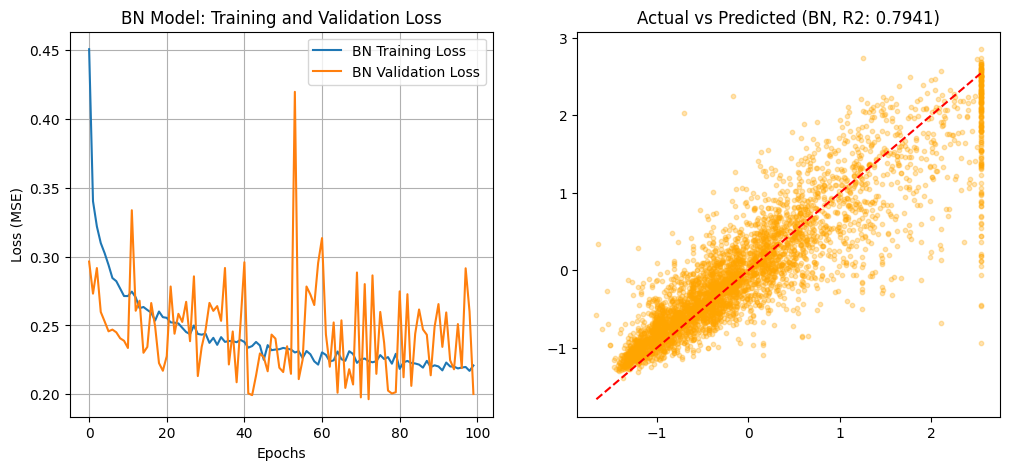


BN Model Predictions (First 10 rows):


,Actual Price (USD),Predicted Price (USD),Absolute Error (Scaled)
0,47700.003906,67881.179688,0.174891
1,45800.003906,119882.781250,0.642005
2,500001.000000,270584.125000,1.988138
3,218600.000000,250339.593750,0.275057
4,278000.000000,262371.500000,0.135437
5,158700.000000,204583.781250,0.397631
6,198200.000000,329843.062500,1.140825
7,157500.000000,186697.937500,0.253031
8,340000.000000,213854.265625,1.093185
9,446600.031250,461272.656250,0.127154


In [ ]:
# 1. Reset tracking variables for Batch Normalization model
train_losses_bn = []
val_losses_bn = []
best_val_loss_bn = float('inf')

# 2. Training Loop with the Improved Model (with BN)
print("Starting training with Dropout and Batch Normalization...")
for epoch in range(NUM_EPOCHS):
    model_bn.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer_bn.zero_grad()
        outputs = model_bn(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_bn.step()
        train_loss += loss.item()

    model_bn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model_bn(batch_X)
            val_loss += criterion(outputs, batch_y).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses_bn.append(train_loss)
    val_losses_bn.append(val_loss)

    if val_loss < best_val_loss_bn:
        best_val_loss_bn = val_loss
        torch.save(model_bn.state_dict(), 'best_model_bn.pth')

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

# 3. Evaluation on Test Set
model_bn.load_state_dict(torch.load('best_model_bn.pth'))
model_bn.eval()
with torch.no_grad():
    y_pred_bn = model_bn(X_test.to(device)).cpu().numpy()
    r2_bn = r2_score(y_test, y_pred_bn)

    # Inverse transform to get actual prices in USD
    y_pred_bn_real = y_scaler.inverse_transform(y_pred_bn)

# 4. Visualization of Results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_bn, label='BN Training Loss')
plt.plot(val_losses_bn, label='BN Validation Loss')
plt.title('BN Model: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_bn, alpha=0.3, color='orange', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Actual vs Predicted (BN, R2: {r2_bn:.4f})')
plt.show()

# 5. Display sample results (First 10 rows)
print("\nBN Model Predictions (First 10 rows):")
comparison_df_bn = pd.DataFrame({
    'Actual Price (USD)': y_true_real.flatten(),
    'Predicted Price (USD)': y_pred_bn_real.flatten(),
    'Absolute Error (Scaled)': np.abs(y_test.numpy().flatten() - y_pred_bn.flatten())
})
display(comparison_df_bn.head(10))

**<font color = 'red'>over regularization !!!</font>**

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (50%)**
   - Proper neural network architecture
   - Correct data preprocessing and feature engineering(if any)
   - Working training loop with validation
   - Appropriate loss function and optimizer

2. **Model Performance (25%)**
   - Reasonable regression metrics (RMSE, MAE, R²)
   - Convergence during training
   - Generalization to test set

3. **Code Quality (25%)**
   - Clean, readable code with comments
   - Efficient implementation
   - Good coding practices
